Total images: 200
Penultimate shape: (200, 2048)
Final shape: (200, 1000)


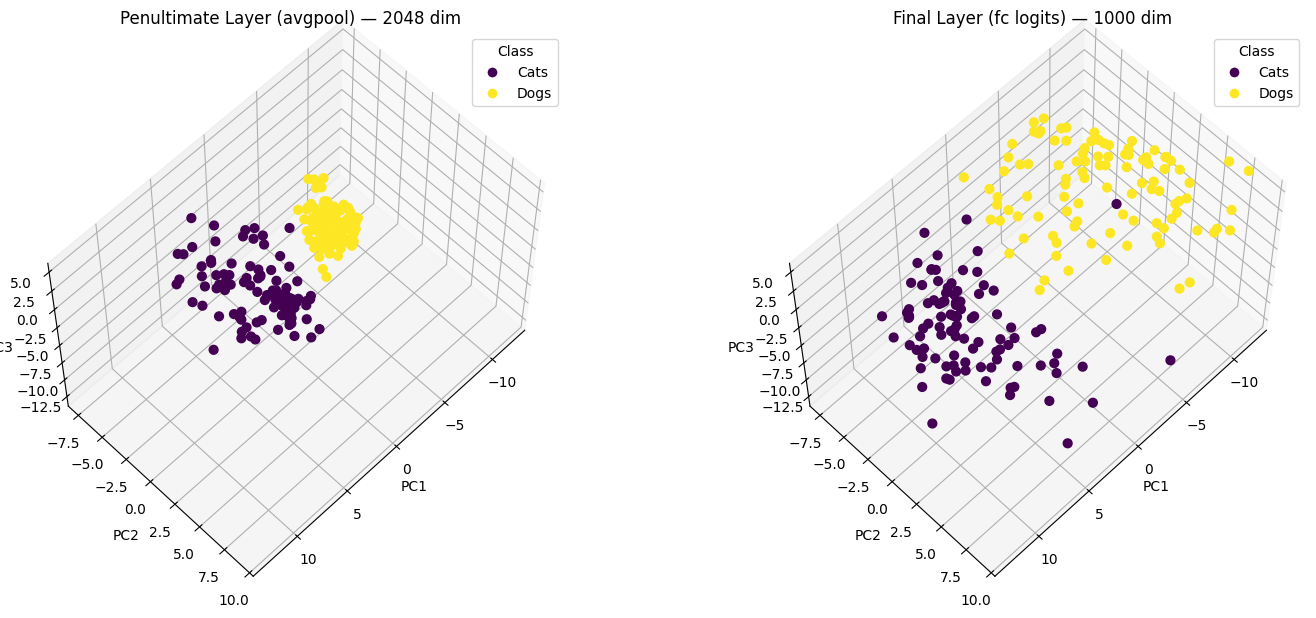

<Figure size 640x480 with 0 Axes>


Observation: Compare how well cats and dogs separate in each layer!


In [2]:
# =========================================================
# ALL-IN-ONE: ResNet50 → Embeddings → PCA → Side-by-Side Plot
# =========================================================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision import models, transforms
from PIL import Image
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D


# ================================
# Load Model
# ================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model = model.to(device)
model.eval()


# ================================
# Image Transform
# ================================
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ================================
# Dataset Loader
# ================================
def load_image(path):
    img = Image.open(path).convert("RGB")
    return transform(img).unsqueeze(0)


# ================================
# Dataset Paths
# ================================
base_folder = "/Users/jaeeponde/Thesis/Data_100"

image_paths = []
image_classes = []

for label in ["Cats", "Dogs"]:
    folder = os.path.join(base_folder, label)

    for f in os.listdir(folder):
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(folder, f))
            image_classes.append(label.lower())

# Limit dataset size (adjust if needed)
image_paths = image_paths[:200]
image_classes = image_classes[:200]

print("Total images:", len(image_paths))


# ================================
# Hook Storage
# ================================
penultimate_outputs = []
final_outputs = []
labels_store = []

current_label = None


# ================================
# Hooks
# ================================
def penultimate_hook(module, input, output):
    out = output.detach().cpu().view(output.size(0), -1)
    penultimate_outputs.append(out.numpy()[0])
    labels_store.append(current_label)

def final_hook(module, input, output):
    out = output.detach().cpu().view(output.size(0), -1)
    final_outputs.append(out.numpy()[0])

hook1 = model.avgpool.register_forward_hook(penultimate_hook)
hook2 = model.fc.register_forward_hook(final_hook)


# ================================
# Forward Pass
# ================================
with torch.no_grad():
    for path, cls in zip(image_paths, image_classes):

        current_label = cls

        img = load_image(path).to(device)
        _ = model(img)


# ================================
# Remove Hooks
# ================================
hook1.remove()
hook2.remove()


# ================================
# Convert To Arrays
# ================================
penultimate_embeddings = np.vstack(penultimate_outputs)
final_embeddings = np.vstack(final_outputs)

labels = labels_store

print("Penultimate shape:", penultimate_embeddings.shape)
print("Final shape:", final_embeddings.shape)


# ================================
# PCA → 3D
# ================================
pca_penult = PCA(n_components=3)
penult_3d = pca_penult.fit_transform(penultimate_embeddings)

pca_final = PCA(n_components=3)
emb_3d = pca_final.fit_transform(final_embeddings)


# ================================
# Colors
# ================================
color_map = {"cats": 0, "dogs": 1}
colors = [color_map[l] for l in labels]
penult_colors = colors


# ================================
# Side-by-Side Plot
# ================================
fig = plt.figure(figsize=(16, 6))

# Penultimate Layer
ax2 = fig.add_subplot(121, projection='3d')
ax2.scatter(
    penult_3d[:, 0], penult_3d[:, 1], penult_3d[:, 2],
    c=penult_colors, cmap='viridis', alpha=1, s=40
)
ax2.set_title(f"Penultimate Layer (avgpool) — {penultimate_embeddings.shape[1]} dim")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_zlabel("PC3")


# Final Layer
ax1 = fig.add_subplot(122, projection='3d')
ax1.scatter(
    emb_3d[:, 0], emb_3d[:, 1], emb_3d[:, 2],
    c=colors, cmap='viridis', alpha=1, s=40
)
ax1.set_title(f"Final Layer (fc logits) — {final_embeddings.shape[1]} dim")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.set_zlabel("PC3")


# ================================
# Match Scale
# ================================
all_points = np.vstack([penult_3d, emb_3d])

x_min, x_max = all_points[:, 0].min(), all_points[:, 0].max()
y_min, y_max = all_points[:, 1].min(), all_points[:, 1].max()
z_min, z_max = all_points[:, 2].min(), all_points[:, 2].max()

for ax in [ax1, ax2]:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_box_aspect([
        x_max - x_min,
        y_max - y_min,
        z_max - z_min
    ])
    ax.view_init(elev=60, azim=45)

# ================================
# Legend (Matches Viridis Mapping Used By Scatter)
# ================================
from matplotlib.lines import Line2D
import matplotlib as mpl

unique_labels = ["cats", "dogs"]

# Recreate same normalization scatter uses
norm = mpl.colors.Normalize(
    vmin=min(color_map.values()),
    vmax=max(color_map.values())
)

cmap = plt.cm.viridis

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=label.capitalize(),
        markerfacecolor=cmap(norm(color_map[label])),
        markersize=8
    )
    for label in unique_labels
]

ax1.legend(handles=legend_elements, title="Class")
ax2.legend(handles=legend_elements, title="Class")


plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

print("\nObservation: Compare how well cats and dogs separate in each layer!")


In [4]:
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt


In [5]:
def mahalanobis_distance(x, mean, cov_inv):
    diff = x - mean
    return np.sqrt(diff @ cov_inv @ diff.T)


In [6]:
def compute_cluster_stats(embeddings, labels):

    classes = sorted(list(set(labels)))
    class_to_idx = {c:i for i,c in enumerate(classes)}

    cluster_means = {}
    cluster_covs = {}
    cluster_cov_invs = {}
    cluster_points = {}

    # -------------------------
    # Per cluster stats
    # -------------------------
    for cls in classes:

        pts = embeddings[np.array(labels) == cls]

        mean = pts.mean(axis=0)
        cov = np.cov(pts, rowvar=False)

        # Regularization (important!)
        cov += np.eye(cov.shape[0]) * 1e-4

        cov_inv = inv(cov)

        cluster_means[cls] = mean
        cluster_covs[cls] = cov
        cluster_cov_invs[cls] = cov_inv
        cluster_points[cls] = pts

    return classes, cluster_means, cluster_covs, cluster_cov_invs, cluster_points


In [7]:
def compute_intra_cluster_distances(classes, cluster_means,
                                    cluster_cov_invs, cluster_points):

    intra = {}

    for cls in classes:

        pts = cluster_points[cls]
        mean = cluster_means[cls]
        cov_inv = cluster_cov_invs[cls]

        dists = [
            mahalanobis_distance(x, mean, cov_inv)
            for x in pts
        ]

        intra[cls] = np.mean(dists)

    return intra


In [8]:
def compute_inter_cluster_distances(classes, cluster_means, cluster_covs):

    inter = {}

    for i, c1 in enumerate(classes):
        for j, c2 in enumerate(classes):

            if i >= j:
                continue

            m1 = cluster_means[c1]
            m2 = cluster_means[c2]

            # pooled covariance
            pooled_cov = (cluster_covs[c1] + cluster_covs[c2]) / 2
            pooled_cov += np.eye(pooled_cov.shape[0]) * 1e-4

            pooled_inv = inv(pooled_cov)

            diff = m1 - m2
            dist = np.sqrt(diff @ pooled_inv @ diff.T)

            inter[(c1, c2)] = dist

    return inter


In [9]:
def plot_intra(intra_dict, title):

    classes = list(intra_dict.keys())
    values = [intra_dict[c] for c in classes]

    plt.figure()
    plt.bar(classes, values)
    plt.ylabel("Avg Mahalanobis Distance")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()


In [10]:
def plot_inter(inter_dict, classes, title):

    n = len(classes)
    mat = np.zeros((n,n))

    for (c1, c2), val in inter_dict.items():
        i = classes.index(c1)
        j = classes.index(c2)
        mat[i,j] = val
        mat[j,i] = val

    plt.figure()
    plt.imshow(mat)
    plt.colorbar(label="Mahalanobis Distance")
    plt.xticks(range(n), classes, rotation=45)
    plt.yticks(range(n), classes)
    plt.title(title)
    plt.show()


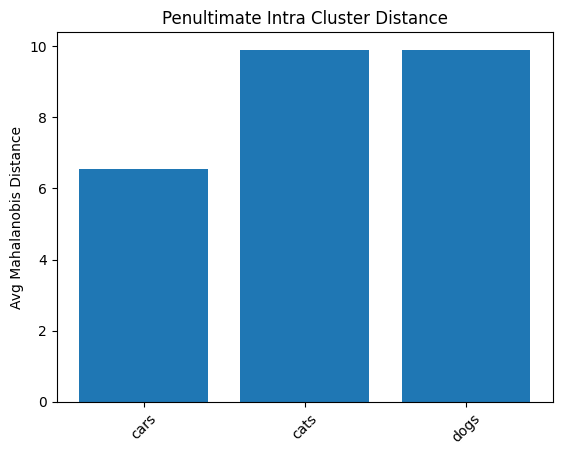

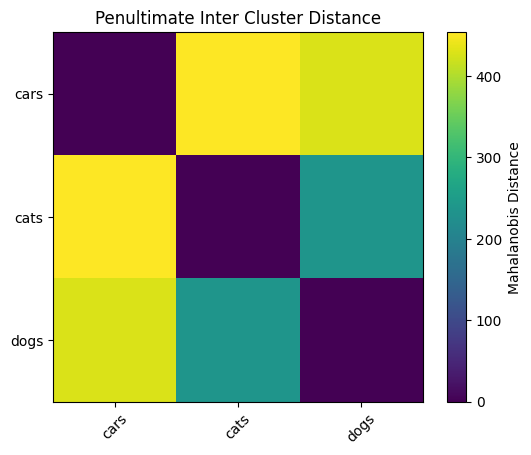

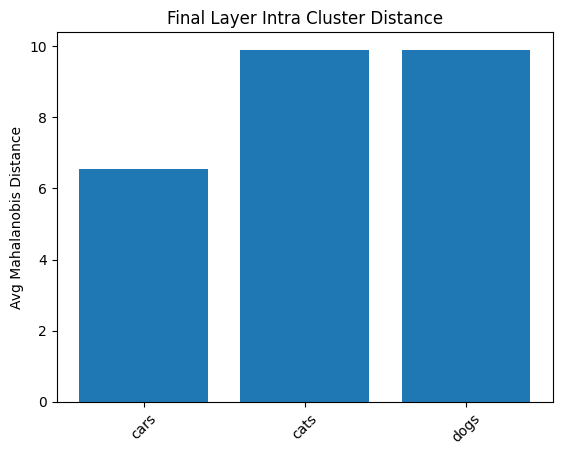

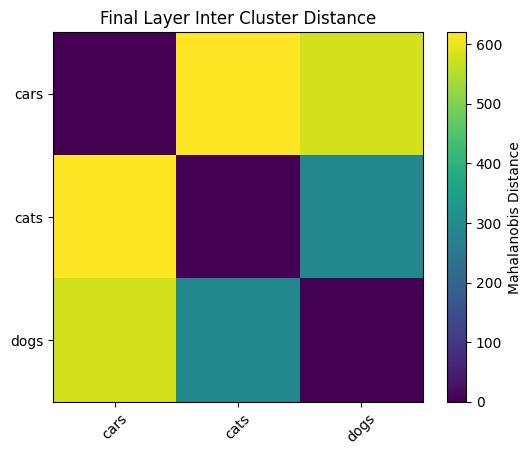

In [11]:
# ======================
# PENULTIMATE
# ======================

classes, means, covs, cov_invs, points = compute_cluster_stats(
    penultimate_embeddings, np.array(labels)
)

intra_pen = compute_intra_cluster_distances(
    classes, means, cov_invs, points
)

inter_pen = compute_inter_cluster_distances(
    classes, means, covs
)

plot_intra(intra_pen, "Penultimate Intra Cluster Distance")
plot_inter(inter_pen, classes, "Penultimate Inter Cluster Distance")


# ======================
# FINAL
# ======================

classes_f, means_f, covs_f, cov_invs_f, points_f = compute_cluster_stats(
    final_embeddings, np.array(labels)
)

intra_fin = compute_intra_cluster_distances(
    classes_f, means_f, cov_invs_f, points_f
)

inter_fin = compute_inter_cluster_distances(
    classes_f, means_f, covs_f
)

plot_intra(intra_fin, "Final Layer Intra Cluster Distance")
plot_inter(inter_fin, classes_f, "Final Layer Inter Cluster Distance")


In [12]:
import numpy as np
from numpy.linalg import inv, pinv


def compute_cluster_stats(embeddings, labels):

    classes = sorted(list(set(labels)))

    cluster_means = {}
    cluster_covs = {}
    cluster_cov_invs = {}
    cluster_points = {}

    for cls in classes:

        pts = embeddings[np.array(labels) == cls]

        mean = pts.mean(axis=0)
        cov = np.cov(pts, rowvar=False)

        # Regularize covariance (important for stability)
        cov += np.eye(cov.shape[0]) * 1e-4

        # Use pseudo inverse (safer than inv)
        cov_inv = pinv(cov)

        cluster_means[cls] = mean
        cluster_covs[cls] = cov
        cluster_cov_invs[cls] = cov_inv
        cluster_points[cls] = pts

    return classes, cluster_means, cluster_covs, cluster_cov_invs, cluster_points
